In [1]:
import pandas as pd

train = pd.read_csv('/Users/eugene/Desktop/Emory/Projects/subrogation-project/data/raw/Training_TriGuard.csv')
test = pd.read_csv('/Users/eugene/Desktop/Emory/Projects/subrogation-project/data/raw/Testing_TriGuard.csv')
test_copy = test.copy()

# Data Cleaning:

## Missing Values:

In [2]:
train.isnull().sum()

subrogation                2
claim_number               0
year_of_born               1
gender                     1
email_or_tel_available     1
safety_rating              1
annual_income              1
high_education_ind         1
address_change_ind         1
living_status              1
zip_code                   1
claim_date                 1
claim_day_of_week          1
accident_site              1
past_num_of_claims         1
witness_present_ind        1
liab_prct                  1
channel                    1
policy_report_filed_ind    1
claim_est_payout           1
vehicle_made_year          1
vehicle_category           1
vehicle_price              1
vehicle_color              1
vehicle_weight             1
age_of_DL                  1
accident_type              1
in_network_bodyshop        1
vehicle_mileage            1
dtype: int64

In [3]:
train.drop(index=8351, inplace=True)
train.loc[8352, 'subrogation'] = 0

# Explanatory Data Analysis:

In [4]:
num_cols = ['year_of_born','safety_rating','annual_income','past_num_of_claims','liab_prct','claim_est_payout','vehicle_price','vehicle_weight','age_of_DL','vehicle_mileage']
cat_cols = ['vehicle_made_year','gender','email_or_tel_available','high_education_ind','address_change_ind','living_status','zip_code','claim_day_of_week','accident_site','witness_present_ind','channel','policy_report_filed_ind','vehicle_category','vehicle_color','accident_type','in_network_bodyshop']

In [5]:
train[num_cols].describe()

,year_of_born,safety_rating,annual_income,past_num_of_claims,liab_prct,claim_est_payout,vehicle_price,vehicle_weight,age_of_DL,vehicle_mileage
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,1980.770500,74.641833,54587.451778,3.634611,38.278278,3602.507022,30657.923288,22842.168655,22.051333,80056.858111
std,12.198355,14.566564,26287.598879,5.603418,9.802537,3609.644983,20636.599225,11857.504523,3.359000,30064.396369
min,1774.000000,2.000000,30015.000000,0.000000,0.000000,65.750000,15000.000000,2450.138635,16.000000,500.000000
25%,1973.000000,65.000000,32193.500000,0.000000,32.000000,1321.807500,15000.000000,14028.319375,20.000000,59587.000000
50%,1982.000000,75.000000,46383.500000,0.000000,38.000000,2414.370000,19637.231880,20672.207015,22.000000,79765.000000
75%,1990.000000,85.000000,67397.000000,6.000000,45.000000,4519.327500,42609.417130,29321.498590,24.000000,100325.750000
max,2008.000000,100.000000,124993.000000,43.000000,84.000000,21504.280000,130000.000000,101818.964200,35.000000,188839.000000


In [6]:
test[num_cols].describe()

,year_of_born,safety_rating,annual_income,past_num_of_claims,liab_prct,claim_est_payout,vehicle_price,vehicle_weight,age_of_DL,vehicle_mileage
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,1980.932000,74.615917,55112.173333,3.661083,38.331500,3636.771014,30422.497617,22986.406280,22.020333,80203.440833
std,11.830499,14.330958,26243.687262,5.608120,9.926034,3658.682182,20688.712540,11946.348839,3.358377,29576.866211
min,1929.000000,18.000000,30015.000000,0.000000,7.000000,58.290000,15000.000000,2591.881965,16.000000,500.000000
25%,1973.000000,65.000000,32606.750000,0.000000,31.000000,1337.940000,15000.000000,14090.729660,20.000000,60280.750000
50%,1982.000000,75.000000,47436.500000,0.000000,38.000000,2415.825000,18793.764395,20861.558420,22.000000,80116.000000
75%,1990.000000,85.000000,68431.250000,6.000000,45.000000,4502.470000,41928.383790,29287.666148,24.000000,100170.250000
max,2009.000000,100.000000,124993.000000,43.000000,79.000000,21504.280000,130000.000000,123016.650400,36.000000,197138.000000


## Target Variable (Subrogation):

In [7]:
train['subrogation'] = train['subrogation'].astype('int').astype('str')

<Axes: xlabel='count', ylabel='subrogation'>

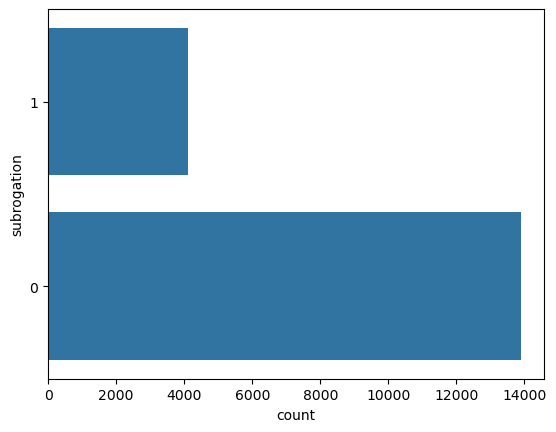

In [8]:
import seaborn as sns
sns.countplot(train.subrogation)

In [9]:
train['subrogation'].value_counts()

subrogation
0    13885
1     4115
Name: count, dtype: int64

### The response class is imbalanced.

## Age:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1841497252.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.year_of_born)


<Axes: xlabel='year_of_born', ylabel='Density'>

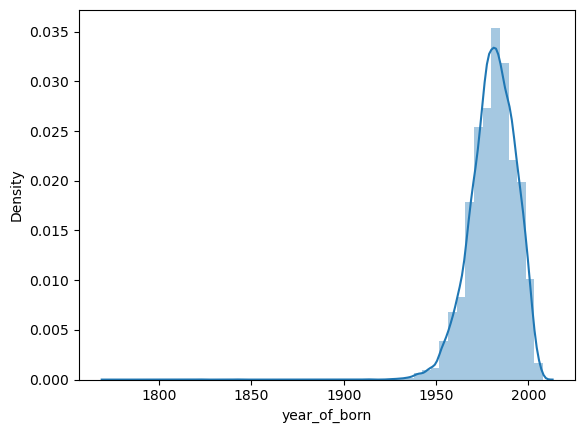

In [10]:
sns.distplot(train.year_of_born)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/179575835.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'year_of_born', data = train,palette='Accent')


<Axes: ylabel='year_of_born'>

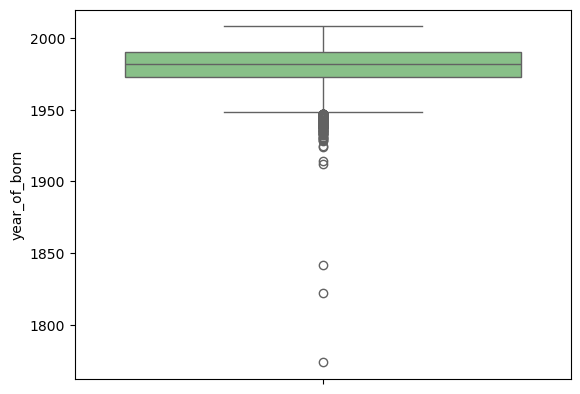

In [11]:
sns.boxplot(y = 'year_of_born', data = train,palette='Accent')

## Gender:

In [12]:
df=train.groupby(['gender','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
df

,gender,subrogation,count
0,F,0,6547
1,F,1,2180
2,M,0,7338
3,M,1,1935


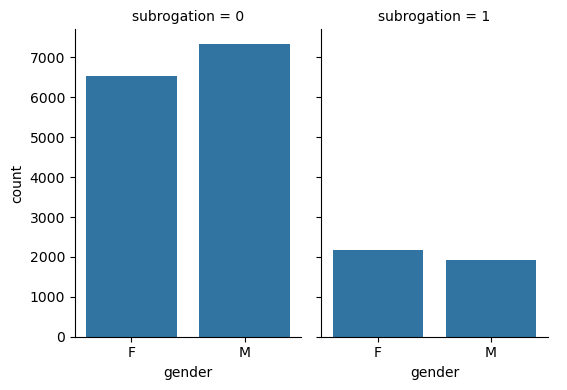

In [13]:
sns.catplot(x="gender", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7);

## Email/Tel:

In [14]:
train['email_or_tel_available'] = train['email_or_tel_available'].astype('int').astype('str')
test['email_or_tel_available'] = test['email_or_tel_available'].astype('int').astype('str')

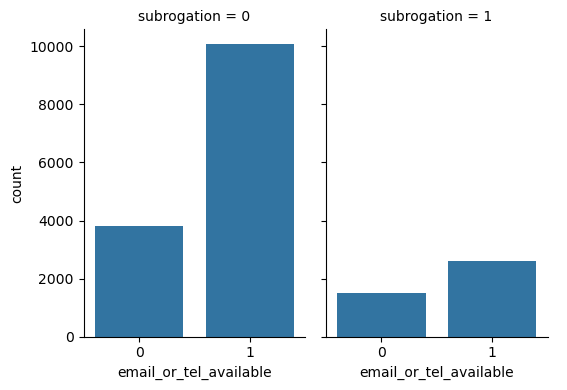

In [15]:
df=train.groupby(['email_or_tel_available','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x="email_or_tel_available", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7);

## Safety Rating:

In [16]:
df=train.groupby(['safety_rating','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
df

,safety_rating,subrogation,count
0,2.0,0,1
1,16.0,0,1
2,20.0,0,2
3,21.0,0,1
4,23.0,0,1
...,...,...,...
150,98.0,1,41
151,99.0,0,110
152,99.0,1,29
153,100.0,0,750


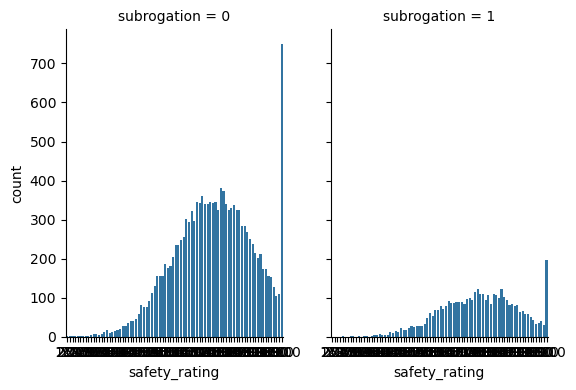

In [17]:
sns.catplot(x="safety_rating", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7);

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/695487879.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'safety_rating', data = train,palette='Accent')


<Axes: ylabel='safety_rating'>

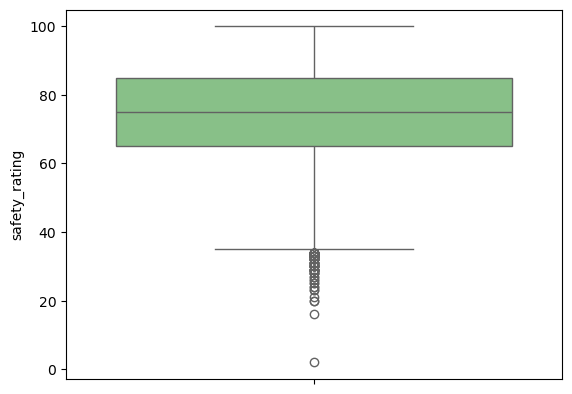

In [18]:
sns.boxplot(y = 'safety_rating', data = train,palette='Accent')

## Annual Income:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1427371766.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.annual_income)


<Axes: xlabel='annual_income', ylabel='Density'>

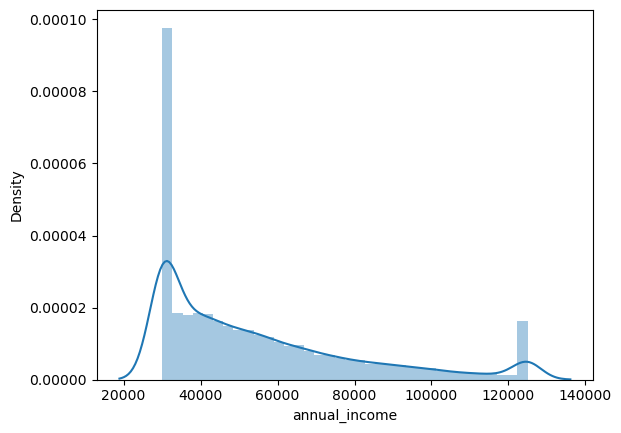

In [19]:
sns.distplot(train.annual_income)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1264403720.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'annual_income', data = train,palette='Accent')


<Axes: ylabel='annual_income'>

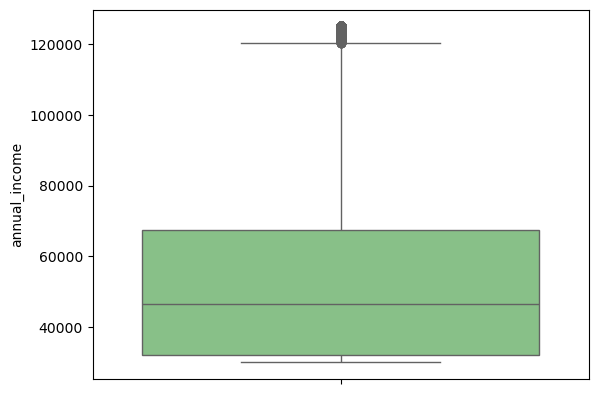

In [20]:
sns.boxplot(y = 'annual_income', data = train,palette='Accent')

## High Education:

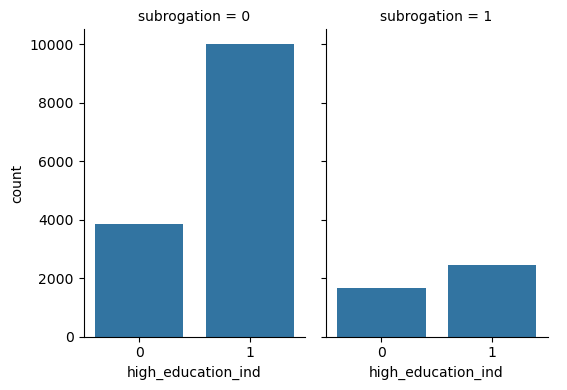

In [21]:
train['high_education_ind'] = train['high_education_ind'].astype('int').astype('str')
test['high_education_ind'] = test['high_education_ind'].astype('int').astype('str')
df=train.groupby(['high_education_ind','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x="high_education_ind", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Address Change:

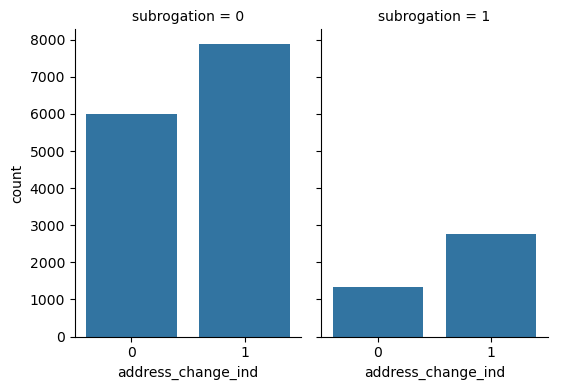

In [22]:
train['address_change_ind'] = train['address_change_ind'].astype('int').astype('str')
test['address_change_ind'] = test['address_change_ind'].astype('int').astype('str')
df=train.groupby(['address_change_ind','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x="address_change_ind", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Living Status:

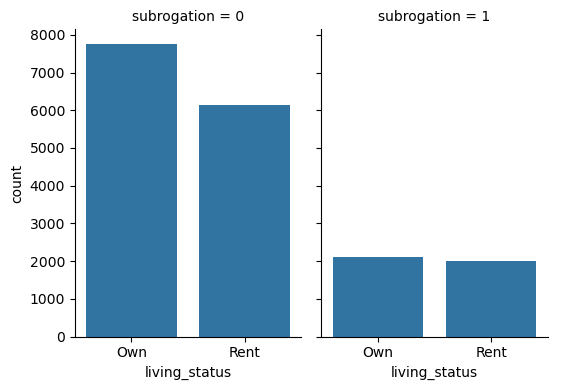

In [23]:
df=train.groupby(['living_status','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x="living_status", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Zipcode:

In [24]:
train['zip_code'] = train['zip_code'].astype('int').astype('str')
test['zip_code'] = test['zip_code'].astype('int').astype('str')

In [25]:
train['zip_code'].describe()

count     18000
unique      276
top       50047
freq        261
Name: zip_code, dtype: object

## Claim Date:

In [26]:
train['claim_date'] = pd.to_datetime(train['claim_date'])
test['claim_date'] = pd.to_datetime(test['claim_date'])

## Claim Day of Week:

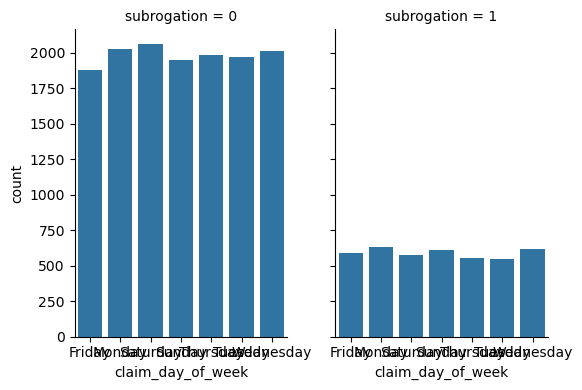

In [27]:
df=train.groupby(['claim_day_of_week','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x="claim_day_of_week", y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Accident Site:

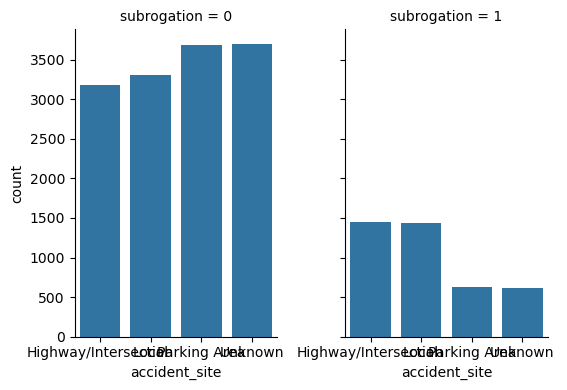

In [28]:
df=train.groupby(['accident_site','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='accident_site', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Past Number of Claims:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2115076219.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.past_num_of_claims)


<Axes: xlabel='past_num_of_claims', ylabel='Density'>

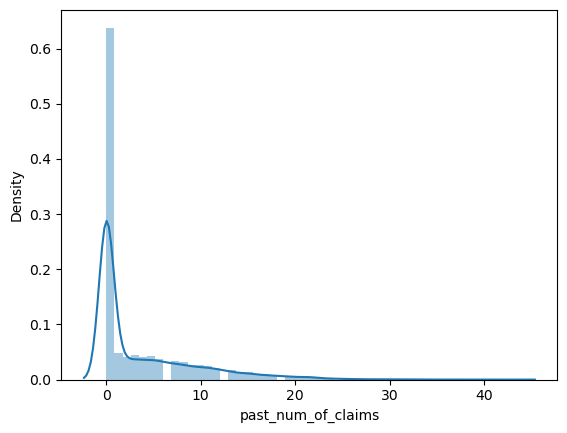

In [29]:
sns.distplot(train.past_num_of_claims)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/970515520.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'past_num_of_claims', data = train,palette='Accent')


<Axes: ylabel='past_num_of_claims'>

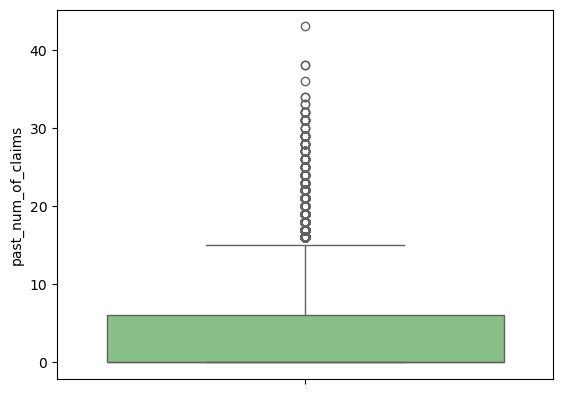

In [30]:
sns.boxplot(y = 'past_num_of_claims', data = train,palette='Accent')

## Witness Presence:

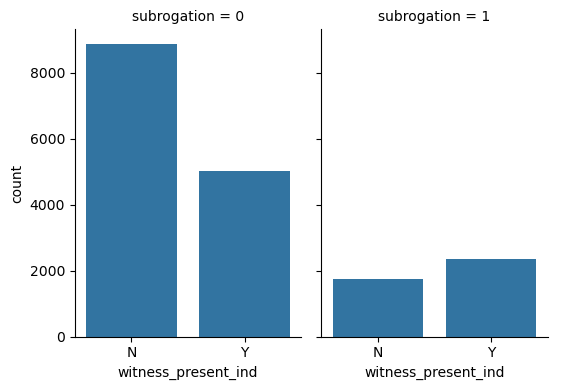

In [31]:
df=train.groupby(['witness_present_ind','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='witness_present_ind', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Liability Percentage:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1811655633.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.liab_prct)


<Axes: xlabel='liab_prct', ylabel='Density'>

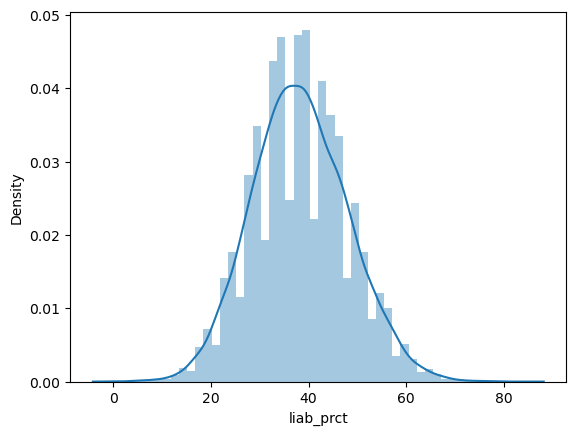

In [32]:
sns.distplot(train.liab_prct)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1668622923.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'liab_prct', data = train,palette='Accent')


<Axes: ylabel='liab_prct'>

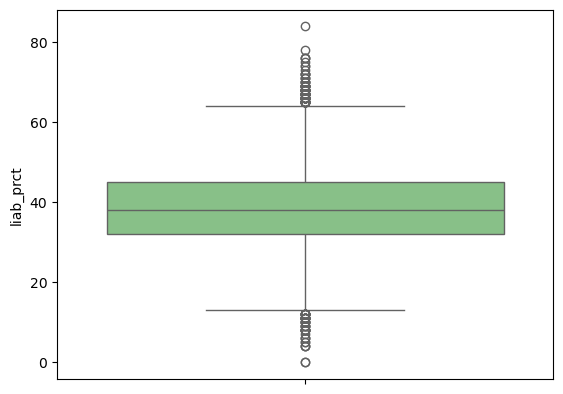

In [33]:
sns.boxplot(y = 'liab_prct', data = train,palette='Accent')

## Channel:

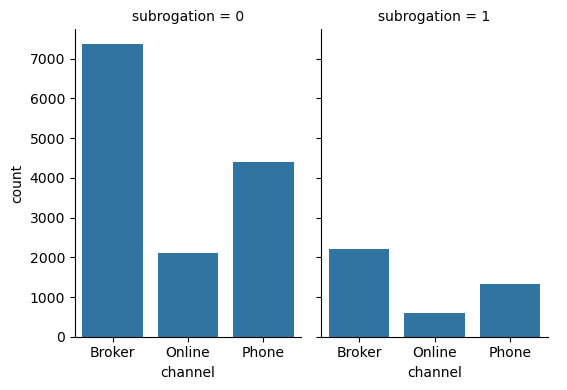

In [34]:
df=train.groupby(['channel','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='channel', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Policy Report:

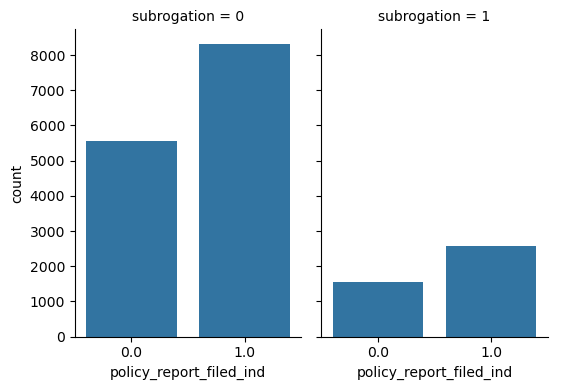

In [35]:
df=train.groupby(['policy_report_filed_ind','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='policy_report_filed_ind', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Estimated Payout:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/649567186.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.claim_est_payout)


<Axes: xlabel='claim_est_payout', ylabel='Density'>

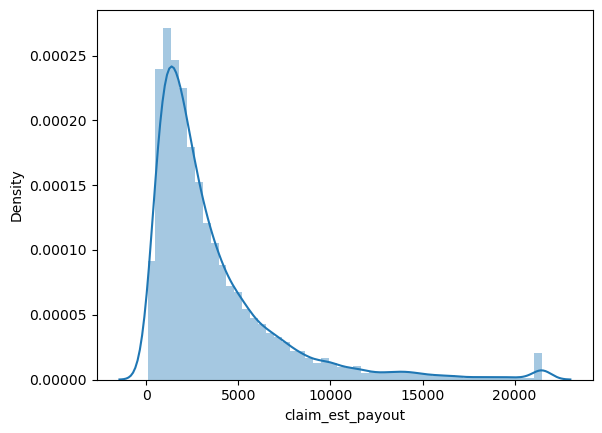

In [36]:
sns.distplot(train.claim_est_payout)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2773439494.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'claim_est_payout', data = train,palette='Accent')


<Axes: ylabel='claim_est_payout'>

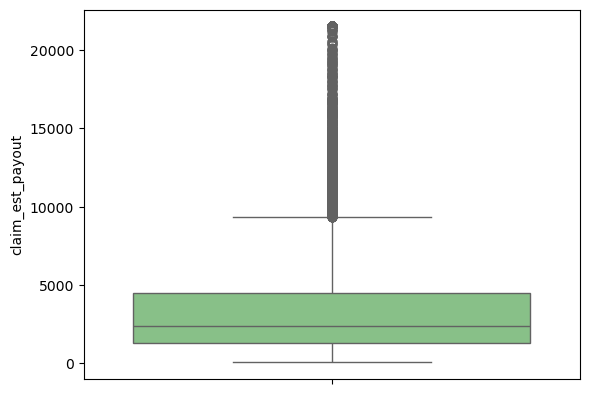

In [37]:
sns.boxplot(y = 'claim_est_payout', data = train,palette='Accent')

## Vehicle Year Made:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1310621862.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.vehicle_made_year)


<Axes: xlabel='vehicle_made_year', ylabel='Density'>

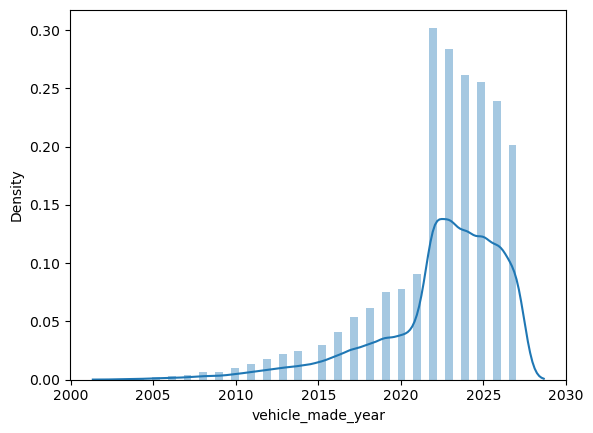

In [38]:
sns.distplot(train.vehicle_made_year)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2834063289.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'vehicle_made_year', data = train,palette='Accent')


<Axes: ylabel='vehicle_made_year'>

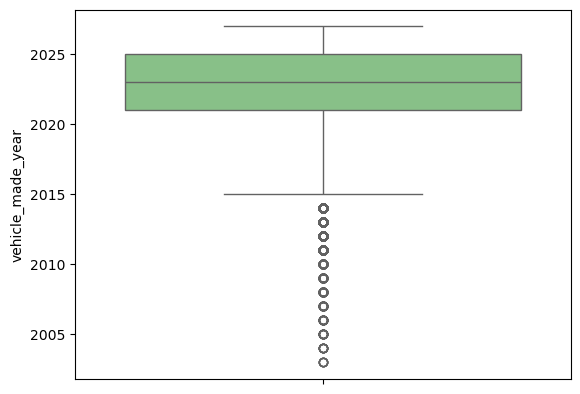

In [39]:
sns.boxplot(y = 'vehicle_made_year', data = train,palette='Accent')

## Vehicle Category:

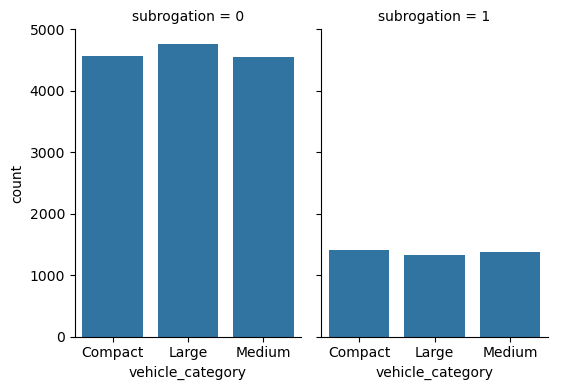

In [40]:
df=train.groupby(['vehicle_category','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='vehicle_category', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Vehicle Price:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3759162883.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.vehicle_price)


<Axes: xlabel='vehicle_price', ylabel='Density'>

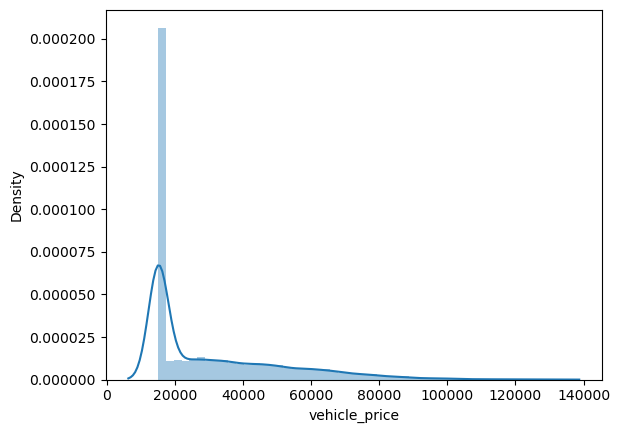

In [41]:
sns.distplot(train.vehicle_price)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/691465254.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'vehicle_price', data = train,palette='Accent')


<Axes: ylabel='vehicle_price'>

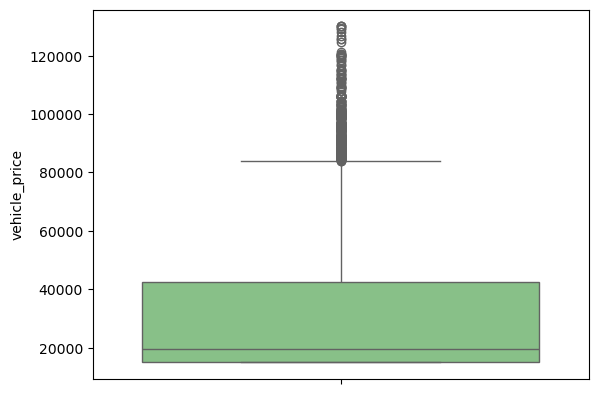

In [42]:
sns.boxplot(y = 'vehicle_price', data = train,palette='Accent')

## Vehicle Color:

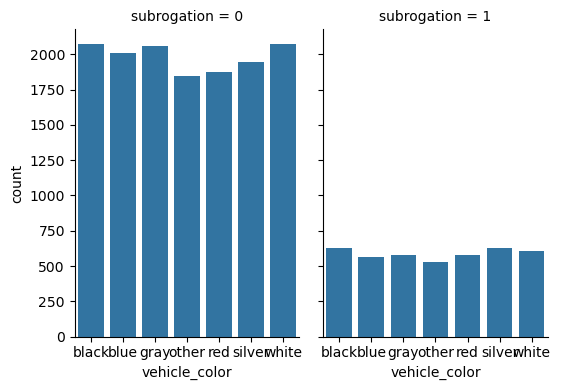

In [43]:
df=train.groupby(['vehicle_color','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='vehicle_color', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Vehicle Weight:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1437310617.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.vehicle_weight)


<Axes: xlabel='vehicle_weight', ylabel='Density'>

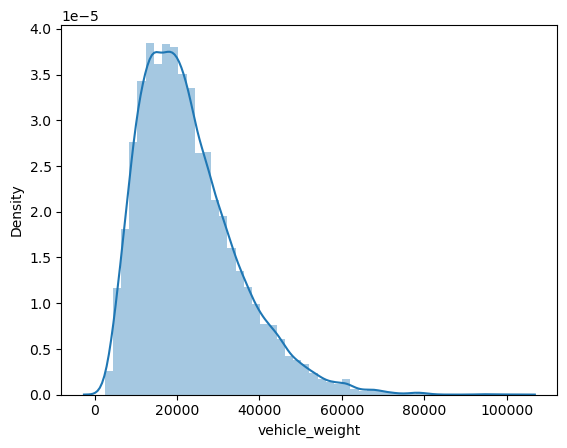

In [44]:
sns.distplot(train.vehicle_weight)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/4177618791.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'vehicle_weight', data = train,palette='Accent')


<Axes: ylabel='vehicle_weight'>

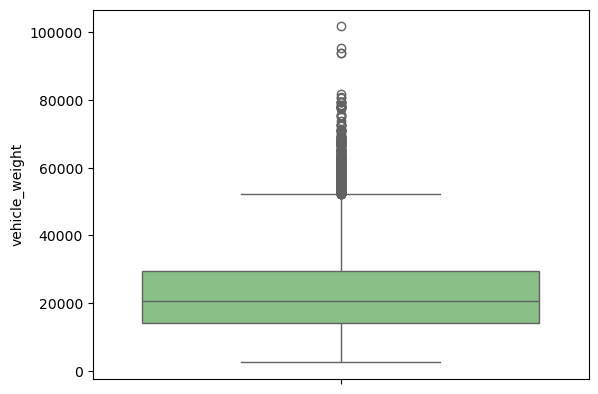

In [45]:
sns.boxplot(y = 'vehicle_weight', data = train,palette='Accent')

## Driver License Age:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2542799406.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.age_of_DL)


<Axes: xlabel='age_of_DL', ylabel='Density'>

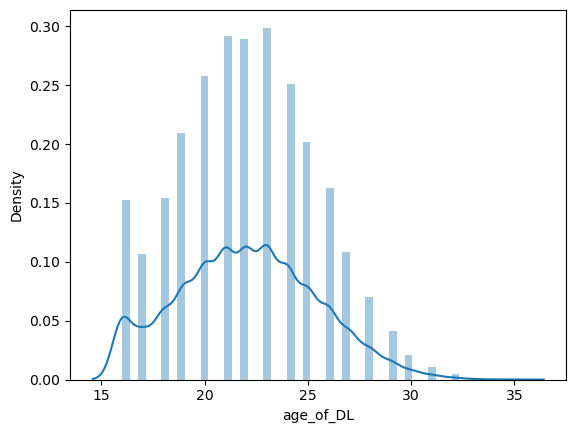

In [46]:
sns.distplot(train.age_of_DL)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1707313063.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'age_of_DL', data = train,palette='Accent')


<Axes: ylabel='age_of_DL'>

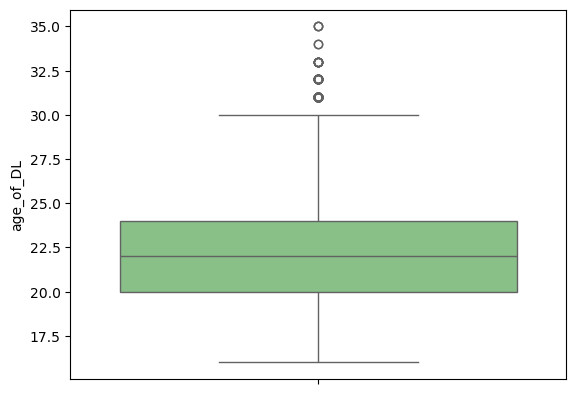

In [47]:
sns.boxplot(y = 'age_of_DL', data = train,palette='Accent')

## Accident Type:

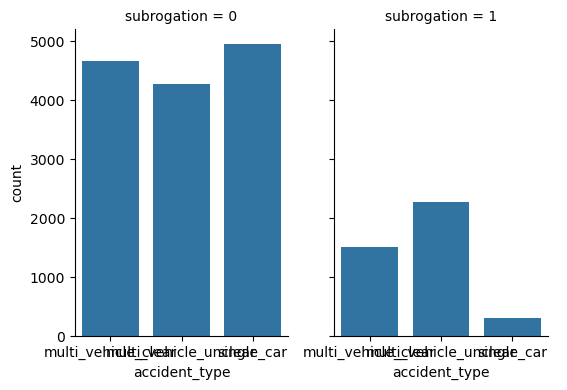

In [48]:
df=train.groupby(['accident_type','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='accident_type', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## In-Network Bodyshop:

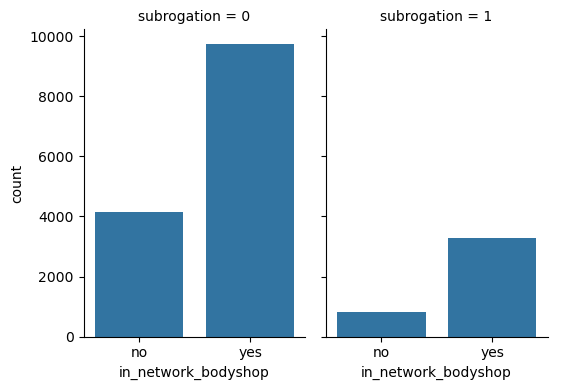

In [49]:
df=train.groupby(['in_network_bodyshop','subrogation'])['claim_number'].count().to_frame().rename(columns={'claim_number':'count'}).reset_index()
sns.catplot(x='in_network_bodyshop', y="count",col="subrogation",
                data=df, kind="bar",
                height=4, aspect=.7)

## Vehicle Mileage:

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/4284654588.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.vehicle_mileage)


<Axes: xlabel='vehicle_mileage', ylabel='Density'>

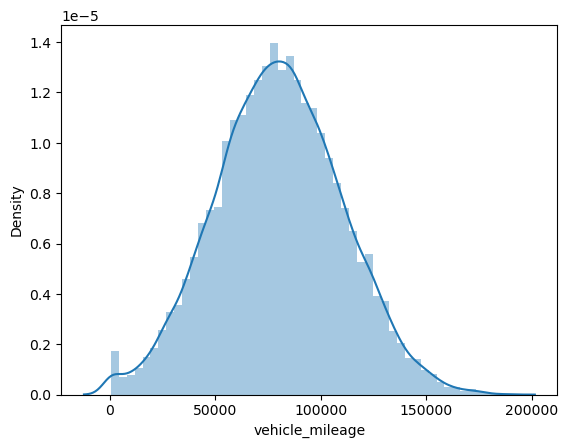

In [50]:
sns.distplot(train.vehicle_mileage)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/821487944.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'vehicle_mileage', data = train,palette='Accent')


<Axes: ylabel='vehicle_mileage'>

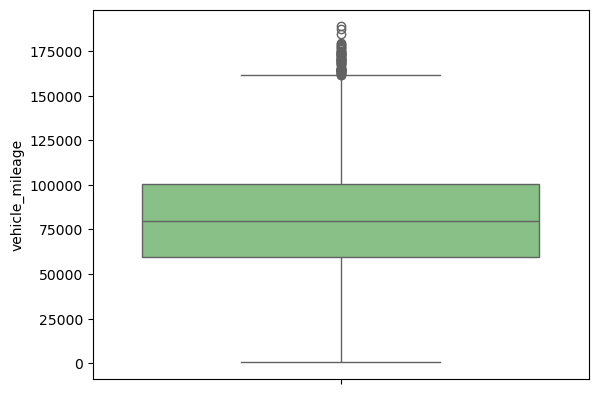

In [51]:
sns.boxplot(y = 'vehicle_mileage', data = train,palette='Accent')

# Feature Engineering:

In [52]:
train['subrogation'] = train['subrogation'].astype('int')

In [53]:
def woe_encode(df, feature, target):
    # Ensure we’re using the Interval type as keys
    categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()

    woe_dict = {}
    for cat in categories:
        pos = ((df[feature] == cat) & (df[target] == 1)).sum()
        neg = ((df[feature] == cat) & (df[target] == 0)).sum()
        woe_dict[cat] = np.log((pos + 0.5) / (neg + 0.5))

    return woe_dict

## Age:

In [54]:
# For Age:
import numpy as np
train[train['year_of_born']< 1928][['year_of_born','claim_date','vehicle_made_year','age_of_DL']]
train['year_of_born'] = np.where(train['year_of_born'] < 1928, 1928, train['year_of_born'])

In [55]:
from sklearn.tree import DecisionTreeClassifier

X = train[['year_of_born']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['birth_year_binned'] = pd.cut(train['year_of_born'], bins=bins)
test['birth_year_binned'] = pd.cut(test['year_of_born'], bins=bins)



Optimal bin edges: [1981.5 1984.5 1993.5 1996.5]


In [56]:
freq_map = train['year_of_born'].value_counts(normalize=True).to_dict()
train['birth_year_freq'] = train['year_of_born'].map(freq_map)
test['birth_year_freq'] = test['year_of_born'].map(freq_map).fillna(0)

In [57]:
mean_target = train.groupby('birth_year_binned')['subrogation'].mean()
train['birth_year_mean'] = train['birth_year_binned'].map(mean_target)
test['birth_year_mean'] = test['birth_year_binned'].map(mean_target)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/4075007190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('birth_year_binned')['subrogation'].mean()


In [58]:
# Build WOE map using train only
woe_map = woe_encode(train, 'birth_year_binned', 'subrogation')

# Apply mapping to train and test
train['birth_year_woe'] = train['birth_year_binned'].map(woe_map)
test['birth_year_woe'] = test['birth_year_binned'].map(woe_map)


/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [59]:
train['age_of_driver'] = train['claim_date'].dt.year - train['year_of_born']
test['age_of_driver'] = test['claim_date'].dt.year - test['year_of_born']

In [60]:
X = train[['age_of_driver']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['driver_age_binned'] = pd.cut(train['age_of_driver'], bins=bins)
test['driver_age_binned'] = pd.cut(test['age_of_driver'], bins=bins)

Optimal bin edges: [19.5 22.5 30.5 34.5]


In [61]:
freq_map = train['age_of_driver'].value_counts(normalize=True).to_dict()
train['driver_age_freq'] = train['age_of_driver'].map(freq_map)
test['driver_age_freq'] = test['age_of_driver'].map(freq_map).fillna(0)

In [62]:
mean_target = train.groupby('driver_age_binned')['subrogation'].mean()
train['driver_age_mean'] = train['driver_age_binned'].map(mean_target)
test['driver_age_mean'] = test['driver_age_binned'].map(mean_target)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3582451762.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('driver_age_binned')['subrogation'].mean()


In [63]:
# Compute WOE mapping on train data
woe_map = woe_encode(train, 'driver_age_binned', 'subrogation')

# Apply mapping to train and test
train['driver_age_woe'] = train['driver_age_binned'].map(woe_map)
test['driver_age_woe'] = test['driver_age_binned'].map(woe_map)


/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Gender:

In [64]:
for dataset in [train, test]:
  dataset['gender'] = dataset['gender'].map({'M':0, 'F':1})

In [65]:
train['subrogation'] = train['subrogation'].astype('int')
mean_target = train.groupby('gender')['subrogation'].mean()
for dataset in [train, test]:
  dataset['gender_mean'] = dataset['gender'].map(mean_target)

In [66]:
freq_map = train['gender'].value_counts(normalize=True).to_dict()
train['gender_freq'] = train['gender'].map(freq_map)
test['gender_freq'] = test['gender'].map(freq_map).fillna(0)

In [67]:
# Compute WOE mapping on train data
woe_map = woe_encode(train, 'gender', 'subrogation')

# Apply mapping to train and test
train['gender_woe'] = train['gender'].map(woe_map)
test['gender_woe'] = test['gender'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Email/Tel:

In [68]:
mean_target = train.groupby('email_or_tel_available')['subrogation'].mean()
train['email_tel_mean'] = train['email_or_tel_available'].map(mean_target)
test['email_tel_mean'] = test['email_or_tel_available'].map(mean_target)

In [69]:
woe_map = woe_encode(train, 'email_or_tel_available', 'subrogation')

train['email_tel_woe'] = train['email_or_tel_available'].map(woe_map)
test['email_tel_woe'] = test['email_or_tel_available'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [70]:
freq_map = train['email_or_tel_available'].value_counts(normalize=True).to_dict()
train['email_tel_freq'] = train['email_or_tel_available'].map(freq_map)
test['email_tel_freq'] = test['email_or_tel_available'].map(freq_map).fillna(0)

## Safety Rating:

In [71]:
X = train[['safety_rating']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['rating_binned'] = pd.cut(train['safety_rating'], bins=bins)
test['rating_binned'] = pd.cut(test['safety_rating'], bins=bins)

Optimal bin edges: [54.5 63.5 72.5 93.5]


In [72]:
mean_target = train.groupby('rating_binned')['subrogation'].mean()
train['safety_rating_mean'] = train['rating_binned'].map(mean_target)
test['safety_rating_mean'] = test['rating_binned'].map(mean_target)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2830555833.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('rating_binned')['subrogation'].mean()


In [73]:
woe_map = woe_encode(train, 'rating_binned', 'subrogation')

# Apply the same mapping to train and test
train['safety_rating_woe'] = train['rating_binned'].map(woe_map)
test['safety_rating_woe'] = test['rating_binned'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [74]:
freq_map = train['rating_binned'].value_counts(normalize=True).to_dict()
train['rating_freq'] = train['rating_binned'].map(freq_map)
test['rating_freq'] = test['rating_binned'].map(freq_map).astype("float").fillna(0)

In [75]:
train['safety_rating_int'] = np.round(train.safety_rating / 10)
test['safety_rating_int'] = np.round(test.safety_rating / 10)

###### something to work on ################################################

In [76]:
from sklearn.preprocessing import StandardScaler

# log-transform: log + square
for dataset in [train, test]:
  dataset['safety_rating'] = np.log(dataset['safety_rating'])
  dataset['safety_rating_2'] = np.square(dataset['safety_rating'])

# standardize
scaler = StandardScaler()
train['safety_rating'] = scaler.fit_transform(train[['safety_rating']])
test['safety_rating'] = scaler.transform(test[['safety_rating']])

scaler = StandardScaler()
train['safety_rating_2'] = scaler.fit_transform(train[['safety_rating_2']])
test['safety_rating_2'] = scaler.transform(test[['safety_rating_2']])

## Annual Income:

In [77]:
X = train[['annual_income']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['income_binned'] = pd.cut(train['annual_income'], bins=bins)
test['income_binned'] = pd.cut(test['annual_income'], bins=bins)

Optimal bin edges: [31434.5 51181.5 55478.  66635.5]


In [78]:
freq_map = train['income_binned'].value_counts(normalize=True).to_dict()
train['income_freq'] = train['income_binned'].map(freq_map)
test['income_freq'] = test['income_binned'].map(freq_map).astype('float').fillna(0)

In [79]:
mean_target = train.groupby('income_binned')['subrogation'].mean()
train['income_mean'] = train['income_binned'].map(mean_target)
test['income_mean'] = test['income_binned'].map(mean_target)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2965266799.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('income_binned')['subrogation'].mean()


In [80]:
woe_map = woe_encode(train, 'income_binned', 'subrogation')

# Apply the same mapping to train and test
train['income_woe'] = train['income_binned'].map(woe_map)
test['income_woe'] = test['income_binned'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [81]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['annual_income'] = np.log(dataset['annual_income'])
  dataset['annual_income_2'] = np.square(dataset['annual_income'])

# standardize
scaler = StandardScaler()
train['annual_income'] = scaler.fit_transform(train[['annual_income']])
test['annual_income'] = scaler.transform(test[['annual_income']])

scaler = StandardScaler()
train['annual_income_2'] = scaler.fit_transform(train[['annual_income_2']])
test['annual_income_2'] = scaler.transform(test[['annual_income_2']])

In [82]:
train['annual_income_int'] = np.round(train.annual_income / 10000)
test['annual_income_int'] = np.round(test.annual_income / 10000)

## High Education:

In [83]:
mean_target = train.groupby('high_education_ind')['subrogation'].mean()
train['education_mean'] = train['high_education_ind'].map(mean_target)
test['education_mean'] = test['high_education_ind'].map(mean_target)

In [84]:
woe_map = woe_encode(train, 'high_education_ind', 'subrogation')

train['education_woe'] = train['high_education_ind'].map(woe_map)
test['education_woe'] = test['high_education_ind'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [85]:
freq_map = train['high_education_ind'].value_counts(normalize=True).to_dict()
train['education_freq'] = train['high_education_ind'].map(freq_map)
test['education_freq'] = test['high_education_ind'].map(freq_map).astype("float").fillna(0)

## Address Change:

In [86]:
mean_target = train.groupby('address_change_ind')['subrogation'].mean()
train['address_mean'] = train['address_change_ind'].map(mean_target)
test['address_mean'] = test['address_change_ind'].map(mean_target)

In [87]:
woe_map = woe_encode(train, 'address_change_ind', 'subrogation')

train['address_woe'] = train['address_change_ind'].map(woe_map)
test['address_woe'] = test['address_change_ind'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [88]:
freq_map = train['address_change_ind'].value_counts(normalize=True).to_dict()
train['address_change_freq'] = train['address_change_ind'].map(freq_map)
test['address_change_freq'] = test['address_change_ind'].map(freq_map).astype("float").fillna(0)

## Living Status:

In [89]:
mean_target = train.groupby('living_status')['subrogation'].mean()
train['living_status_mean'] = train['living_status'].map(mean_target)
test['living_status_mean'] = test['living_status'].map(mean_target)

In [90]:
woe_map = woe_encode(train, 'living_status', 'subrogation')

train['living_status_woe'] = train['living_status'].map(woe_map)
test['living_status_woe'] = test['living_status'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [91]:
freq_map = train['living_status'].value_counts(normalize=True).to_dict()
train['living_status_freq'] = train['living_status'].map(freq_map)
test['living_status_freq'] = test['living_status'].map(freq_map).astype("float").fillna(0)

## Zipcode:

In [92]:
# truncating last 2 digits of zip_code
train['zip_code'] = train['zip_code'].astype(int)
test['zip_code'] = test['zip_code'].astype(int)
train['zipcode_binned'] = np.round(train.zip_code / 100)
test['zipcode_binned'] = np.round(test.zip_code / 100)

In [93]:
mean_target = train.groupby('zipcode_binned')['subrogation'].mean()
train['zipcode_mean'] = train['zipcode_binned'].map(mean_target)
test['zipcode_mean'] = test['zipcode_binned'].map(mean_target)

In [94]:
woe_map = woe_encode(train, 'zipcode_binned', 'subrogation')

train['zipcode_woe'] = train['zipcode_binned'].map(woe_map)
test['zipcode_woe'] = test['zipcode_binned'].map(woe_map)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [95]:
freq_map = train['zipcode_binned'].value_counts(normalize=True).to_dict()
train['zipcode_freq'] = train['zipcode_binned'].map(freq_map)
test['zipcode_freq'] = test['zipcode_binned'].map(freq_map).astype("float").fillna(0)

## Claim Date:

In [96]:
# Derive time-based features
for dataset in [train, test]:
    dataset['claim_year'] = dataset['claim_date'].dt.year
    dataset['claim_month'] = dataset['claim_date'].dt.month
    dataset['claim_day_of_week_int'] = dataset['claim_date'].dt.dayofweek
    dataset['is_weekend'] = dataset['claim_date'].dt.dayofweek.isin([5,6]).astype(int)
    # extracting claim_date_delta
    dataset['claim_date_delta'] = (dataset['claim_date'] - dataset['claim_date'].min())
    dataset['claim_date_delta'] = dataset['claim_date_delta'].apply(lambda x: str(x).split()[0]).astype(int)
    #dataset.drop(['claim_date'], axis = 1, inplace = True)

In [97]:
X = train[['claim_year']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['claim_year_binned'] = pd.cut(train['claim_year'], bins=bins)
test['claim_year_binned'] = pd.cut(test['claim_year'], bins=bins)

Optimal bin edges: [2015.5]


In [98]:
X = train[['claim_date_delta']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['date_delta_binned'] = pd.cut(train['claim_date_delta'], bins=bins)
test['date_delta_binned'] = pd.cut(test['claim_date_delta'], bins=bins)

Optimal bin edges: [411.5 447.5 490.5 676.5]


In [99]:
for dataset in [train, test]:
  for col in ['claim_year_binned','claim_month','claim_day_of_week_int','is_weekend','date_delta_binned']:
    mean_target = train.groupby(col)['subrogation'].mean()
    dataset[f'{col}_mean'] = dataset[col].map(mean_target)
    woe_map = woe_encode(train, col, 'subrogation')
    dataset[f'{col}_woe'] = dataset[col].map(woe_map)
    freq_map = train[col].value_counts(normalize=True).to_dict()
    dataset[f'{col}_freq'] = dataset[col].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1308076587.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby(col)['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.ty

## Claim Day of Week:

In [100]:
for dataset in [train, test]:
    mean_target = train.groupby('claim_day_of_week')['subrogation'].mean()
    dataset['day_of_week_mean'] = dataset['claim_day_of_week'].map(mean_target)
    woe_map = woe_encode(train, 'claim_day_of_week', 'subrogation')
    dataset['day_of_week_woe'] = dataset['claim_day_of_week'].map(woe_map)
    freq_map = train['claim_day_of_week'].value_counts(normalize=True).to_dict()
    dataset['day_of_week_freq'] = dataset['claim_day_of_week'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Accident Site:

In [101]:
for dataset in [train, test]:
    mean_target = train.groupby('accident_site')['subrogation'].mean()
    dataset['accident_site_mean'] = dataset['accident_site'].map(mean_target)
    woe_map = woe_encode(train, 'accident_site', 'subrogation')
    dataset['accident_site_woe'] = dataset['accident_site'].map(woe_map)
    freq_map = train['accident_site'].value_counts(normalize=True).to_dict()
    dataset['accident_site_freq'] = dataset['accident_site'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Past Number of Claims:

In [102]:
X = train[['past_num_of_claims']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['past_claims_binned'] = pd.cut(train['past_num_of_claims'], bins=bins)
test['past_claims_binned'] = pd.cut(test['past_num_of_claims'], bins=bins)

Optimal bin edges: [ 4.5  6.5  9.5 12.5]


In [103]:
for dataset in [train, test]:
    mean_target = train.groupby('past_claims_binned')['subrogation'].mean()
    dataset['past_claims_mean'] = dataset['past_claims_binned'].map(mean_target)
    woe_map = woe_encode(train, 'past_claims_binned', 'subrogation')
    dataset['past_claims_woe'] = dataset['past_claims_binned'].map(woe_map)
    freq_map = train['past_claims_binned'].value_counts(normalize=True).to_dict()
    dataset['past_claims_freq'] = dataset['past_claims_binned'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1614287181.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('past_claims_binned')['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1614287181.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

In [104]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['past_num_of_claims'] = np.log1p(dataset['past_num_of_claims'])
  dataset['past_num_of_claims_2'] = np.square(dataset['past_num_of_claims'])

# standardize
scaler = StandardScaler()
train['past_num_of_claims'] = scaler.fit_transform(train[['past_num_of_claims']])
test['past_num_of_claims'] = scaler.transform(test[['past_num_of_claims']])

scaler = StandardScaler()
train['past_num_of_claims_2'] = scaler.fit_transform(train[['past_num_of_claims_2']])
test['past_num_of_claims_2'] = scaler.transform(test[['past_num_of_claims_2']])

## Witness Presence:

In [105]:
for dataset in [train, test]:
    mean_target = train.groupby('witness_present_ind')['subrogation'].mean()
    dataset['witness_mean'] = dataset['witness_present_ind'].map(mean_target)
    woe_map = woe_encode(train, 'witness_present_ind', 'subrogation')
    dataset['witness_woe'] = dataset['witness_present_ind'].map(woe_map)
    freq_map = train['witness_present_ind'].value_counts(normalize=True).to_dict()
    dataset['witness_freq'] = dataset['witness_present_ind'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Liability Percentage:

In [106]:
X = train[['liab_prct']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['liab_binned'] = pd.cut(train['liab_prct'], bins=bins)
test['liab_binned'] = pd.cut(test['liab_prct'], bins=bins)

Optimal bin edges: [33.5 38.5 41.5 44.5]


In [107]:
for dataset in [train, test]:
    mean_target = train.groupby('liab_binned')['subrogation'].mean()
    dataset['liab_mean'] = dataset['liab_binned'].map(mean_target)
    woe_map = woe_encode(train, 'liab_binned', 'subrogation')
    dataset['liab_woe'] = dataset['liab_binned'].map(woe_map)
    freq_map = train['liab_binned'].value_counts(normalize=True).to_dict()
    dataset['liab_freq'] = dataset['liab_binned'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2463258273.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('liab_binned')['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2463258273.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt

## Channel:

In [108]:
for dataset in [train, test]:
    mean_target = train.groupby('channel')['subrogation'].mean()
    dataset['channel_mean'] = dataset['channel'].map(mean_target)
    woe_map = woe_encode(train, 'channel', 'subrogation')
    dataset['channel_woe'] = dataset['channel'].map(woe_map)
    freq_map = train['channel'].value_counts(normalize=True).to_dict()
    dataset['channel_freq'] = dataset['channel'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Policy Report:

In [109]:
for dataset in [train, test]:
    mean_target = train.groupby('policy_report_filed_ind')['subrogation'].mean()
    dataset['policy_report_mean'] = dataset['policy_report_filed_ind'].map(mean_target)
    woe_map = woe_encode(train, 'policy_report_filed_ind', 'subrogation')
    dataset['policy_report_woe'] = dataset['policy_report_filed_ind'].map(woe_map)
    freq_map = train['policy_report_filed_ind'].value_counts(normalize=True).to_dict()
    dataset['policy_report_freq'] = dataset['policy_report_filed_ind'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Estimated Payout:

In [110]:
X = train[['claim_est_payout']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['payout_binned'] = pd.cut(train['claim_est_payout'], bins=bins)
test['payout_binned'] = pd.cut(test['claim_est_payout'], bins=bins)

Optimal bin edges: [ 548.88998413  782.33499146  979.48999023 1441.31500244]


In [111]:
for dataset in [train, test]:
    mean_target = train.groupby('payout_binned')['subrogation'].mean()
    dataset['payout_mean'] = dataset['payout_binned'].map(mean_target)
    woe_map = woe_encode(train, 'payout_binned', 'subrogation')
    dataset['payout_woe'] = dataset['payout_binned'].map(woe_map)
    freq_map = train['payout_binned'].value_counts(normalize=True).to_dict()
    dataset['payout_freq'] = dataset['payout_binned'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3608182125.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('payout_binned')['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3608182125.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

In [112]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['claim_est_payout'] = np.log(dataset['claim_est_payout'])
  dataset['claim_est_payout_2'] = np.square(dataset['claim_est_payout'])

# standardize
scaler = StandardScaler()
train['claim_est_payout'] = scaler.fit_transform(train[['claim_est_payout']])
test['claim_est_payout'] = scaler.transform(test[['claim_est_payout']])

scaler = StandardScaler()
train['claim_est_payout_2'] = scaler.fit_transform(train[['claim_est_payout_2']])
test['claim_est_payout_2'] = scaler.transform(test[['claim_est_payout_2']])

## Vehicle Year Made:

In [113]:
X = train[['vehicle_made_year']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['vehicle_made_year_binned'] = pd.cut(train['vehicle_made_year'], bins=bins)
test['vehicle_made_year_binned'] = pd.cut(test['vehicle_made_year'], bins=bins)

Optimal bin edges: [2014.5 2018.5 2020.5 2025.5]


In [114]:
train['vehicle_age'] = train['claim_year'] - train['vehicle_made_year']
test['vehicle_age'] = test['claim_year'] - test['vehicle_made_year']

In [115]:
X = train[['vehicle_age']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['vehicle_age_binned'] = pd.cut(train['vehicle_age'], bins=bins)
test['vehicle_age_binned'] = pd.cut(test['vehicle_age'], bins=bins)

Optimal bin edges: [-6.5 -4.5 -2.5  0.5]


In [116]:
for dataset in [train, test]:
  for col in ['vehicle_made_year_binned','vehicle_age_binned']:
    mean_target = train.groupby(col)['subrogation'].mean()
    dataset[f'{col}_mean'] = dataset[col].map(mean_target)
    woe_map = woe_encode(train, col, 'subrogation')
    dataset[f'{col}_woe'] = dataset[col].map(woe_map)
    freq_map = train[col].value_counts(normalize=True).to_dict()
    dataset[f'{col}_freq'] = dataset[col].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2868287093.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby(col)['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2868287093.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

In [117]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['vehicle_age'] = np.log1p(dataset['vehicle_age'] + abs(dataset['vehicle_age'].min())+1)
  dataset['vehicle_age_2'] = np.square(dataset['vehicle_age'])

# standardize
scaler = StandardScaler()
train['vehicle_age'] = scaler.fit_transform(train[['vehicle_age']])
test['vehicle_age'] = scaler.transform(test[['vehicle_age']])

scaler = StandardScaler()
train['vehicle_age_2'] = scaler.fit_transform(train[['vehicle_age_2']])
test['vehicle_age_2'] = scaler.transform(test[['vehicle_age_2']])

## Vehicle Category:

In [118]:
for dataset in [train, test]:
    mean_target = train.groupby('vehicle_category')['subrogation'].mean()
    dataset['vehicle_category_mean'] = dataset['vehicle_category'].map(mean_target)
    woe_map = woe_encode(train, 'vehicle_category', 'subrogation')
    dataset['vehicle_category_woe'] = dataset['vehicle_category'].map(woe_map)
    freq_map = train['vehicle_category'].value_counts(normalize=True).to_dict()
    dataset['vehicle_category_freq'] = dataset['vehicle_category'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Vehicle Price:

In [119]:
X = train[['vehicle_price']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['vehicle_price_binned'] = pd.cut(train['vehicle_price'], bins=bins)
test['vehicle_price_binned'] = pd.cut(test['vehicle_price'], bins=bins)

Optimal bin edges: [18984.79589844 32362.60644531 57587.50195312 66859.875     ]


In [120]:
for dataset in [train, test]:
    mean_target = train.groupby('vehicle_price')['subrogation'].mean()
    dataset['vehicle_price_mean'] = dataset['vehicle_price'].map(mean_target).fillna(0)
    woe_map = woe_encode(train, 'vehicle_price', 'subrogation')
    dataset['vehicle_price_woe'] = dataset['vehicle_price'].map(woe_map)
    freq_map = train['vehicle_price'].value_counts(normalize=True).to_dict()
    dataset['vehicle_price_freq'] = dataset['vehicle_price'].map(freq_map).astype("float").fillna(0)

test['vehicle_price_woe'] = test['vehicle_price_woe'].fillna(test['vehicle_price_woe'].mean())

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [121]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['vehicle_price'] = np.log(dataset['vehicle_price'])
  dataset['vehicle_price_2'] = np.square(dataset['vehicle_price'])

# standardize
scaler = StandardScaler()
train['vehicle_price'] = scaler.fit_transform(train[['vehicle_price']])
test['vehicle_price'] = scaler.transform(test[['vehicle_price']])

scaler = StandardScaler()
train['vehicle_price_2'] = scaler.fit_transform(train[['vehicle_price_2']])
test['vehicle_price_2'] = scaler.transform(test[['vehicle_price_2']])

## Vehicle Color:

In [122]:
for dataset in [train, test]:
    mean_target = train.groupby('vehicle_color')['subrogation'].mean()
    dataset['vehicle_color_mean'] = dataset['vehicle_color'].map(mean_target)
    woe_map = woe_encode(train, 'vehicle_color', 'subrogation')
    dataset['vehicle_color_woe'] = dataset['vehicle_color'].map(woe_map)
    freq_map = train['vehicle_color'].value_counts(normalize=True).to_dict()
    dataset['vehicle_color_freq'] = dataset['vehicle_color'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


## Vehicle Weight:

In [123]:
X = train[['vehicle_weight']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['vehicle_weight_binned'] = pd.cut(train['vehicle_weight'], bins=bins)
test['vehicle_weight_binned'] = pd.cut(test['vehicle_weight'], bins=bins)

Optimal bin edges: [23079.43554688 27797.31933594 30117.66992188 39816.06640625]


In [124]:
for dataset in [train, test]:
    mean_target = train.groupby('vehicle_weight')['subrogation'].mean()
    dataset['vehicle_weight_mean'] = dataset['vehicle_weight'].map(mean_target).fillna(0)
    woe_map = woe_encode(train, 'vehicle_weight', 'subrogation')
    dataset['vehicle_weight_woe'] = dataset['vehicle_weight'].map(woe_map)
    freq_map = train['vehicle_weight'].value_counts(normalize=True).to_dict()
    dataset['vehicle_weight_freq'] = dataset['vehicle_weight'].map(freq_map).astype("float").fillna(0)

test['vehicle_weight_woe'] = test['vehicle_weight_woe'].fillna(test['vehicle_weight_woe'].mean())

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()


In [125]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['vehicle_weight'] = np.log(dataset['vehicle_weight'])
  dataset['vehicle_weight_2'] = np.square(dataset['vehicle_weight'])

# standardize
scaler = StandardScaler()
train['vehicle_weight'] = scaler.fit_transform(train[['vehicle_weight']])
test['vehicle_weight'] = scaler.transform(test[['vehicle_weight']])

scaler = StandardScaler()
train['vehicle_weight_2'] = scaler.fit_transform(train[['vehicle_weight_2']])
test['vehicle_weight_2'] = scaler.transform(test[['vehicle_weight_2']])

## Driver License Age:

In [126]:
X = train[['age_of_DL']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['age_of_DL_binned'] = pd.cut(train['age_of_DL'], bins=bins)
test['age_of_DL_binned'] = pd.cut(test['age_of_DL'], bins=bins)

Optimal bin edges: [19.5 20.5 24.5 25.5]


In [127]:
for dataset in [train, test]:
    mean_target = train.groupby('age_of_DL_binned')['subrogation'].mean()
    dataset['age_of_DL_mean'] = dataset['age_of_DL_binned'].map(mean_target)
    woe_map = woe_encode(train, 'age_of_DL_binned', 'subrogation')
    dataset['age_of_DL_woe'] = dataset['age_of_DL_binned'].map(woe_map)
    freq_map = train['age_of_DL_binned'].value_counts(normalize=True).to_dict()
    dataset['age_of_DL_freq'] = dataset['age_of_DL_binned'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2873748143.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('age_of_DL_binned')['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/2873748143.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [128]:
# log-transform: log + square
for dataset in [train, test]:
  dataset['age_of_DL'] = np.log(dataset['age_of_DL'])
  dataset['age_of_DL_2'] = np.square(dataset['age_of_DL'])

# standardize
scaler = StandardScaler()
train['age_of_DL'] = scaler.fit_transform(train[['age_of_DL']])
test['age_of_DL'] = scaler.transform(test[['age_of_DL']])

scaler = StandardScaler()
train['age_of_DL_2'] = scaler.fit_transform(train[['age_of_DL_2']])
test['age_of_DL_2'] = scaler.transform(test[['age_of_DL_2']])

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1413574871.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['age_of_DL_2'] = np.square(dataset['age_of_DL'])
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1413574871.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['age_of_DL_2'] = np.square(dataset['age_of_DL'])


## Accident Type:

In [129]:
for dataset in [train, test]:
    mean_target = train.groupby('accident_type')['subrogation'].mean()
    dataset['accident_type_mean'] = dataset['accident_type'].map(mean_target)
    woe_map = woe_encode(train, 'accident_type', 'subrogation')
    dataset['accident_type_woe'] = dataset['accident_type'].map(woe_map)
    freq_map = train['accident_type'].value_counts(normalize=True).to_dict()
    dataset['accident_type_freq'] = dataset['accident_type'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3776076201.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['accident_type_mean'] = dataset['accident_type'].map(mean_target)
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3776076201.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

## In-Network Bodyshop:

In [130]:
for dataset in [train, test]:
    mean_target = train.groupby('in_network_bodyshop')['subrogation'].mean()
    dataset['bodyshop_mean'] = dataset['in_network_bodyshop'].map(mean_target)
    woe_map = woe_encode(train, 'in_network_bodyshop', 'subrogation')
    dataset['bodyshop_woe'] = dataset['in_network_bodyshop'].map(woe_map)
    freq_map = train['in_network_bodyshop'].value_counts(normalize=True).to_dict()
    dataset['bodyshop_freq'] = dataset['in_network_bodyshop'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3308742371.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['bodyshop_mean'] = dataset['in_network_bodyshop'].map(mean_target)
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categories = df[feature].cat.categories if pd.api.types.is_categorical_dtype(df[feature]) else df[feature].unique()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/3308742371.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

## Vehicle Mileage:

In [131]:
X = train[['vehicle_mileage']]
y = train['subrogation']

tree = DecisionTreeClassifier(
    max_leaf_nodes=5,
    min_samples_leaf=0.05,
)
tree.fit(X, y)

thresholds = np.sort(tree.tree_.threshold[tree.tree_.threshold != -2])
print("Optimal bin edges:", thresholds)

bins = [-np.inf] + list(thresholds) + [np.inf]
train['mileage_binned'] = pd.cut(train['vehicle_mileage'], bins=bins)
test['mileage_binned'] = pd.cut(test['vehicle_mileage'], bins=bins)

Optimal bin edges: [ 30684.  85900. 101392. 107659.]


/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1321511051.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['mileage_binned'] = pd.cut(train['vehicle_mileage'], bins=bins)
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/1321511051.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['mileage_binned'] = pd.cut(test['vehicle_mileage'], bins=bins)


In [132]:
for dataset in [train, test]:
    mean_target = train.groupby('mileage_binned')['subrogation'].mean()
    dataset['mileage_mean'] = dataset['mileage_binned'].map(mean_target)
    woe_map = woe_encode(train, 'mileage_binned', 'subrogation')
    dataset['mileage_woe'] = dataset['mileage_binned'].map(woe_map)
    freq_map = train['mileage_binned'].value_counts(normalize=True).to_dict()
    dataset['mileage_freq'] = dataset['mileage_binned'].map(freq_map).astype("float").fillna(0)

/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/153697060.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = train.groupby('mileage_binned')['subrogation'].mean()
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/153697060.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['mileage_mean'] = dataset['mileage_binned'].map(mean_target)
/var/folders/xm/p4wfyxkx4q74ck673pbnpxkh0000gn/T/ipykernel_1230/309688818.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinst

# Feature Crossing:

In [133]:
categorical_cols = ['gender','email_or_tel_available','high_education_ind','address_change_ind',
                    'living_status','zip_code','claim_date','claim_day_of_week','accident_site',
                    'witness_present_ind','channel','policy_report_filed_ind','vehicle_category',
                    'vehicle_color','accident_type','in_network_bodyshop','birth_year_binned',
                    'driver_age_binned','rating_binned','income_binned','zipcode_binned',
                    'claim_year','claim_month','claim_day_of_week_int','is_weekend',
                    'claim_date_delta','claim_year_binned','date_delta_binned',
                    'past_claims_binned','liab_binned','payout_binned','vehicle_made_year_binned',
                    'vehicle_age_binned','vehicle_price_binned','vehicle_weight_binned','age_of_DL_binned',
                    'mileage_binned','annual_income_int', 'past_claims_binned','safety_rating_int']

numerical_cols = ['year_of_born','safety_rating','annual_income','past_num_of_claims',
                  'liab_prct','claim_est_payout','vehicle_made_year','vehicle_price',
                  'vehicle_weight','age_of_DL','vehicle_mileage','birth_year_freq',
                  'birth_year_mean','birth_year_woe','age_of_driver','driver_age_freq',
                  'driver_age_mean','driver_age_woe','gender_mean','gender_freq','gender_woe',
                  'email_tel_mean','email_tel_woe','email_tel_freq','safety_rating_mean',
                  'safety_rating_woe','rating_freq','safety_rating_2','income_freq',
                  'income_mean','income_woe','annual_income_2','education_mean','education_woe',
                  'education_freq','address_mean','address_woe','address_change_freq',
                  'living_status_mean','living_status_woe','living_status_freq',
                  'zipcode_mean','zipcode_woe','zipcode_freq',
                  'claim_year_binned_mean','claim_year_binned_woe','claim_year_binned_freq',
                  'claim_month_mean','claim_month_woe','claim_month_freq',
                  'claim_day_of_week_int_mean','claim_day_of_week_int_woe',
                  'claim_day_of_week_int_freq','is_weekend_mean','is_weekend_woe',
                  'is_weekend_freq','date_delta_binned_mean','date_delta_binned_woe',
                  'date_delta_binned_freq','day_of_week_mean','day_of_week_woe',
                  'day_of_week_freq','accident_site_mean','accident_site_woe',
                  'accident_site_freq','past_claims_mean','past_claims_woe','past_claims_freq',
                  'past_num_of_claims_2','witness_mean','witness_woe','witness_freq',
                  'liab_mean','liab_woe','liab_freq','channel_mean','channel_woe','channel_freq',
                  'policy_report_mean','policy_report_woe','policy_report_freq','payout_mean',
                  'payout_woe','payout_freq','claim_est_payout_2','vehicle_age',
                  'vehicle_made_year_binned_mean','vehicle_made_year_binned_woe',
                  'vehicle_made_year_binned_freq','vehicle_age_binned_mean',
                  'vehicle_age_binned_woe','vehicle_age_binned_freq','vehicle_age_2',
                  'vehicle_category_mean','vehicle_category_woe','vehicle_category_freq',
                  'vehicle_price_mean','vehicle_price_woe',
                  'vehicle_price_freq','vehicle_price_2','vehicle_color_mean','vehicle_color_woe',
                  'vehicle_color_freq','vehicle_weight_mean','vehicle_weight_woe',
                  'vehicle_weight_freq','vehicle_weight_2','age_of_DL_mean','age_of_DL_woe',
                  'age_of_DL_freq','age_of_DL_2','accident_type_mean','accident_type_woe',
                  'accident_type_freq','bodyshop_mean','bodyshop_woe','bodyshop_freq',
                  'mileage_mean','mileage_woe','mileage_freq']
all_cols = categorical_cols + numerical_cols

## One Hot Encoding:

In [134]:
# Encode train and test
train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=False)
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=False)

# ✅ Align columns to make sure train/test have same dummy columns
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

In [135]:
from sklearn.preprocessing import PolynomialFeatures

# Suppose num_cols is your list of numeric columns
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Fit and transform on your train data
X_train_interact = poly.fit_transform(train[numerical_cols])
X_test_interact = poly.transform(test[numerical_cols])

# Get feature names for the new crossed features
crossed_feature_names = poly.get_feature_names_out(numerical_cols)

# Turn them into DataFrames
X_train_interact = pd.DataFrame(X_train_interact, columns=crossed_feature_names, index=train.index)
X_test_interact = pd.DataFrame(X_test_interact, columns=crossed_feature_names, index=test.index)


In [136]:
train = pd.concat([train, train_encoded], axis=1)
test = pd.concat([test, test_encoded], axis=1)

train_combined = pd.concat([train[numerical_cols], X_train_interact, train_encoded], axis=1)
test_combined  = pd.concat([test[numerical_cols], X_test_interact, test_encoded], axis=1)
train_combined, test_combined = train_combined.align(test_combined, join='left', axis=1, fill_value=0)

In [137]:
train_combined = train_combined.loc[:, ~train_combined.columns.duplicated()]
test_combined  = test_combined.loc[:, ~test_combined.columns.duplicated()]

train = train.loc[:, ~train.columns.duplicated()]
test  = test.loc[:, ~test.columns.duplicated()]

In [138]:
train_combined['subrogation'] = train['subrogation']

print("Train shape:", train_combined.shape)
print("Test shape:", test_combined.shape)

Train shape: (18000, 9160)
Test shape: (12000, 9160)


# Feature Selection:

In [139]:
# Compute correlations
corr_list = []
train_combined['subrogation'] = pd.to_numeric(train_combined['subrogation'], errors='coerce')
full_num = train_combined.columns.tolist()
for col in full_num:
    if col == 'subrogation':
        continue  # skip target
    # Convert to numeric in case column is object
    series_col = pd.to_numeric(train_combined[col], errors='coerce')
    # Skip column if all values are NaN
    if series_col.isna().all():
        continue
    # Compute Pearson correlation
    corr = series_col.corr(train_combined['subrogation'])
    corr_list.append((col, 'subrogation', corr))

# Convert to DataFrame
corr_df = pd.DataFrame(corr_list, columns=['variable', 'target', 'correlation'])

# Sort by absolute correlation
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values(by='abs_corr', ascending=False).drop(columns='abs_corr')
corr_df.reset_index(drop=True, inplace=True)
corr_df

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,variable,target,correlation
0,vehicle_weight_mean,subrogation,1.000000
1,claim_year_binned_mean vehicle_weight_mean,subrogation,0.999999
2,claim_year_binned_woe vehicle_weight_mean,subrogation,-0.999999
3,vehicle_made_year vehicle_weight_mean,subrogation,0.999997
4,year_of_born vehicle_weight_mean,subrogation,0.999976
...,...,...,...
9154,claim_date_2015-02-23 00:00:00,subrogation,-0.000004
9155,claim_date_delta_53,subrogation,-0.000004
9156,claim_date_delta_396,subrogation,-0.000004
9157,claim_date_2016-02-01 00:00:00,subrogation,-0.000004


In [140]:
cols_to_drop = corr_df[abs(corr_df['correlation'])<0.1]['variable'].tolist()
train_combined = train_combined.drop(columns=cols_to_drop)
test_combined = test_combined.drop(columns=cols_to_drop)

## AutoGluon Setup:

In [141]:
%pip install autogluon

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with 

# Model Fitting:

## Vehicle Weight Mean:

In [142]:
cols = [c for c in train_combined.columns if "vehicle_weight_mean" in c]
X = train_combined[cols]
y = train_combined['subrogation']

# perform basic fitting to understand predictive power
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py)

In [ ]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score

weight_mean_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
weight_mean_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9719, number of negative: 9719
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1241
[LightGBM] [Info] Number of data points in the train set: 19438, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

Pipeline(steps=[('scalar', StandardScaler()),
                ('oversample', RandomOverSampler(random_state=42)),
                ('lgbm', LGBMClassifier())])

In [ ]:
nested_scores = cross_val_score(weight_mean_model, X_test, y_test, cv=5, scoring=make_scorer(f1_score, pos_label=1), n_jobs=-1)
print("Nested CV F1 (mean ± std): {:.4f} ± {:.4f}".format(nested_scores.mean(), nested_scores.std()))
# extremely strong predictive power -> no need to do autogluon

Nested CV F1 (mean ± std): 1.0000 ± 0.0000


In [ ]:
# use the entire training set to train the model and predict
weight_mean_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
weight_mean_model.fit(X, y)
pred_weight_mean = weight_mean_model.predict(test_combined[cols]).flatten()

[LightGBM] [Info] Number of positive: 13885, number of negative: 13885
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1252
[LightGBM] [Info] Number of data points in the train set: 27770, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# submission 1
submission_weight_mean = pd.DataFrame({
    'claim_number': test_copy['claim_number'],
    'subrogation': pred_weight_mean
})
submission_weight_mean.to_csv('submission_weight_mean.csv')

## Vehicle Weight WOE:

In [ ]:
cols = [c for c in train_combined.columns if "vehicle_weight_woe" in c and "vehicle_weight_mean" not in c]
X = train_combined[cols]
y = train_combined['subrogation']

# perform basic training to understand predictive power
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score

weight_woe_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
weight_woe_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9719, number of negative: 9719
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7038
[LightGBM] [Info] Number of data points in the train set: 19438, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

Pipeline(steps=[('scalar', StandardScaler()),
                ('oversample', RandomOverSampler(random_state=42)),
                ('lgbm', LGBMClassifier())])

In [ ]:
nested_scores = cross_val_score(weight_woe_model, X_test, y_test, cv=5, scoring=make_scorer(f1_score, pos_label=1), n_jobs=-1)
print("Nested CV F1 (mean ± std): {:.4f} ± {:.4f}".format(nested_scores.mean(), nested_scores.std()))
# very strong predictive power -> no need to do autogluon

Nested CV F1 (mean ± std): 1.0000 ± 0.0000


In [ ]:
# use the entire training set to fit the model and predict
weight_woe_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
weight_woe_model.fit(X, y)
pred_weight_woe = weight_woe_model.predict(test_combined[cols]).flatten()

[LightGBM] [Info] Number of positive: 13885, number of negative: 13885
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7126
[LightGBM] [Info] Number of data points in the train set: 27770, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# submission 2
submission_weight_woe = pd.DataFrame({
    'claim_number': test_copy['claim_number'],
    'subrogation': pred_weight_woe
})
submission_weight_woe.to_csv('submission_weight_woe.csv')

## Vehicle Price Mean:

In [ ]:
cols = [c for c in train_combined.columns if "vehicle_price_mean" in c and "vehicle_weight_mean" not in c and "vehicle_weight_woe" not in c]
X = train_combined[cols]
y = train_combined['subrogation']

# fit basic model
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score

price_mean_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
price_mean_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 9719, number of negative: 9719
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2474
[LightGBM] [Info] Number of data points in the train set: 19438, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Pipeline(steps=[('scalar', StandardScaler()),
                ('oversample', RandomOverSampler(random_state=42)),
                ('lgbm', LGBMClassifier())])

In [ ]:
nested_scores = cross_val_score(price_mean_model, X_test, y_test, cv=5, scoring=make_scorer(f1_score, pos_label=1), n_jobs=-1)
print("Nested CV F1 (mean ± std): {:.4f} ± {:.4f}".format(nested_scores.mean(), nested_scores.std()))
# relatively strong predictive power -> perform autogluon

Nested CV F1 (mean ± std): 0.8003 ± 0.0136


In [ ]:
# prediction from basic training
# for sanity checks, not used for submission
price_mean_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
price_mean_model.fit(X, y)
pred_price_mean = price_mean_model.predict(test_combined[cols]).flatten()

[LightGBM] [Info] Number of positive: 13885, number of negative: 13885
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2506
[LightGBM] [Info] Number of data points in the train set: 27770, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Autogluon:

In [ ]:
cols = cols + ['subrogation']
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    train_combined[cols], test_size=0.3, random_state=42, stratify=train_combined['subrogation']
)

predictor = TabularPredictor(
    label='subrogation',
    eval_metric='f1'  # use F1 score as evaluation
).fit(train_data=train_df)

predictor.leaderboard(test_df, silent=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20251209_192207"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Memory Avail:       8.22 GB / 12.67 GB (64.9%)
Disk Space Avail:   62.34 GB / 107.72 GB (57.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='b

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.818884,0.811111,f1,0.038545,0.009414,3.288439,0.038545,0.009414,3.288439,1,True,2
1,CatBoost,0.816695,0.801512,f1,0.017380,0.004637,9.425205,0.017380,0.004637,9.425205,1,True,5
2,NeuralNetTorch,0.815618,0.815642,f1,0.179007,0.089386,17.083035,0.179007,0.089386,17.083035,1,True,10
3,XGBoost,0.814083,0.819549,f1,0.039975,0.009867,3.437076,0.039975,0.009867,3.437076,1,True,9
4,NeuralNetFastAI,0.812526,0.819672,f1,0.093734,0.052263,17.621183,0.093734,0.052263,17.621183,1,True,8
5,LightGBMXT,0.811135,0.815642,f1,0.077664,0.017737,7.485633,0.077664,0.017737,7.485633,1,True,1
6,WeightedEnsemble_L2,0.806061,0.826168,f1,0.094088,0.023025,10.183935,0.002988,0.003034,0.501482,2,True,12
7,RandomForestGini,0.805115,0.796935,f1,0.209224,0.176910,4.761495,0.209224,0.176910,4.761495,1,True,3
8,RandomForestEntr,0.804739,0.794574,f1,0.226063,0.134925,4.373410,0.226063,0.134925,4.373410,1,True,4
9,LightGBMLarge,0.804007,0.821561,f1,0.051124,0.010123,6.245377,0.051124,0.010123,6.245377,1,True,11


In [ ]:
# use the best performing model with validation score with the intent of introducing overfitting
# because of highly similar distribution of variables, this is a special case where overfitting is a good thing
best_model = TabularPredictor.load("/content/AutogluonModels/ag-20251209_192207") # hard coded from output above
pred_price_mean = best_model.predict(test_combined[cols], model = 'WeightedEnsemble_L2')

In [ ]:
# submission 3
submission_price_mean = pd.DataFrame({
    'claim_number': test_copy['claim_number'],
    'subrogation': pred_price_mean
})

submission_price_mean.to_csv('submission_price_mean.csv')

## Vehicle Price WOE:

In [ ]:
cols = [c for c in train_combined.columns if "vehicle_price_woe" in c and "vehicle_price_mean" not in c and "vehicle_weight_mean" not in c and "vehicle_weight_woe" not in c]
X = train_combined[cols]
y = train_combined['subrogation']

# fit training set
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score

price_woe_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
price_woe_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('oversample', RandomOverSampler(random_state=42)),
                ('lgbm', LGBMClassifier())])

In [ ]:
nested_scores = cross_val_score(price_woe_model, X_test, y_test, cv=5, scoring=make_scorer(f1_score, pos_label=1), n_jobs=-1)
print("Nested CV F1 (mean ± std): {:.4f} ± {:.4f}".format(nested_scores.mean(), nested_scores.std()))
# not really predictive -> perform autogluon

Nested CV F1 (mean ± std): 0.7990 ± 0.0163


In [ ]:
# for sanity checking
price_woe_model = Pipeline([
    ('scalar', StandardScaler()) ,
    ('oversample', RandomOverSampler(random_state=42)),
    ('lgbm', LGBMClassifier())
])
price_woe_model.fit(X, y)
pred_price_woe = price_woe_model.predict(test_combined[cols]).flatten()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Autogluon:

In [ ]:
cols = cols + ['subrogation']
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    train_combined[cols], test_size=0.3, random_state=42, stratify=train_combined['subrogation']
)

predictor = TabularPredictor(
    label='subrogation',
    eval_metric='f1'  # use F1 score as evaluation
).fit(train_data=train_df)

predictor.leaderboard(test_df, silent=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20251209_193759"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Memory Avail:       7.45 GB / 12.67 GB (58.8%)
Disk Space Avail:   62.19 GB / 107.72 GB (57.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='b

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,0.815986,0.827715,f1,0.245805,0.052042,7.696196,0.245805,0.052042,7.696196,1,True,1
1,NeuralNetTorch,0.813828,0.810526,f1,0.220847,0.086843,17.271733,0.220847,0.086843,17.271733,1,True,10
2,WeightedEnsemble_L2,0.811620,0.831169,f1,0.707222,0.265263,30.331088,0.004105,0.002545,0.497733,2,True,12
3,NeuralNetFastAI,0.810429,0.819923,f1,0.100879,0.037342,16.608359,0.100879,0.037342,16.608359,1,True,8
4,CatBoost,0.809019,0.803774,f1,0.016930,0.019301,24.748141,0.016930,0.019301,24.748141,1,True,5
5,XGBoost,0.801253,0.820416,f1,0.056777,0.011592,4.659932,0.056777,0.011592,4.659932,1,True,9
6,LightGBM,0.800356,0.811215,f1,0.028511,0.009192,8.854477,0.028511,0.009192,8.854477,1,True,2
7,LightGBMLarge,0.799111,0.825046,f1,0.048219,0.009074,12.335049,0.048219,0.009074,12.335049,1,True,11
8,RandomForestEntr,0.793810,0.803810,f1,0.236466,0.123832,4.865426,0.236466,0.123832,4.865426,1,True,4
9,RandomForestGini,0.793607,0.799242,f1,0.256471,0.109012,9.802786,0.256471,0.109012,9.802786,1,True,3


In [ ]:
# choose best model from validation score because we love overfitting
best_model = TabularPredictor.load("/content/AutogluonModels/ag-20251209_193759") # hard coded
pred_price_woe = best_model.predict(test_combined[cols], model = 'WeightedEnsemble_L2')

In [ ]:
# submission 4
submission_price_woe = pd.DataFrame({
    'claim_number': test_copy['claim_number'],
    'subrogation': pred_price_woe
})

submission_price_woe.to_csv('submission_price_woe.csv')

## All Others: (for exploration)

In [ ]:
# cols = [c for c in train_combined.columns if "vehicle_price_woe" not in c and "vehicle_price_mean" not in c and "vehicle_weight_mean" not in c and "vehicle_weight_woe" not in c and "subrogation" not in c]
# X = train_combined[cols]
# y = train_combined['subrogation']

# # basic model training
# from imblearn.over_sampling import RandomOverSampler
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

In [ ]:
# from lightgbm import LGBMClassifier
# from imblearn.pipeline import Pipeline
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
# from sklearn.metrics import make_scorer, f1_score

# others_model = Pipeline([
#     ('scalar', StandardScaler()) ,
#     ('oversample', RandomOverSampler(random_state=42)),
#     ('lgbm', LGBMClassifier())
# ])
# others_model.fit(X_train, y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('oversample', RandomOverSampler(random_state=42)),
                ('lgbm', LGBMClassifier())])

In [ ]:
# nested_scores = cross_val_score(others_model, X_test, y_test, cv=5, scoring=make_scorer(f1_score, pos_label=1), n_jobs=-1)
# print("Nested CV F1 (mean ± std): {:.4f} ± {:.4f}".format(nested_scores.mean(), nested_scores.std()))
# low performing -> use autogluon, but not expecting much improvements either

Nested CV F1 (mean ± std): 0.5819 ± 0.0199


In [ ]:
# for sanity checking
# others_model = Pipeline([
#     ('scalar', StandardScaler()) ,
#     ('oversample', RandomOverSampler(random_state=42)),
#     ('lgbm', LGBMClassifier())
# ])
# others_model.fit(X, y)
# pred_others = others_model.predict(test_combined[cols]).flatten()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Autogluon:

In [ ]:
# cols = cols + ['subrogation']
# from autogluon.tabular import TabularDataset, TabularPredictor
# from sklearn.model_selection import train_test_split
# train_df, test_df = train_test_split(
#     train_combined[cols], test_size=0.3, random_state=42, stratify=train_combined['subrogation']
# )

# predictor = TabularPredictor(
#     label='subrogation',
#     eval_metric='f1'  # use F1 score as evaluation
# ).fit(train_data=train_df)

# predictor.leaderboard(test_df, silent=True)

No path specified. Models will be saved in: "AutogluonModels/ag-20251209_183621"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Memory Avail:       6.31 GB / 12.67 GB (49.8%)
Disk Space Avail:   62.69 GB / 107.72 GB (58.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='b

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.583197,0.619863,f1,0.467506,0.412525,212.155787,0.003613,0.002615,0.477203,2,True,12
1,NeuralNetFastAI,0.580336,0.608108,f1,0.356325,0.252821,91.969955,0.356325,0.252821,91.969955,1,True,8
2,NeuralNetTorch,0.557971,0.593985,f1,0.472559,0.219718,41.013928,0.472559,0.219718,41.013928,1,True,10
3,LightGBM,0.555246,0.570312,f1,0.279764,0.056200,49.247035,0.279764,0.056200,49.247035,1,True,2
4,LightGBMXT,0.554048,0.565815,f1,0.197881,0.041667,38.576191,0.197881,0.041667,38.576191,1,True,1
5,CatBoost,0.548964,0.553106,f1,0.107568,0.157089,119.708628,0.107568,0.157089,119.708628,1,True,5
6,XGBoost,0.545623,0.549801,f1,0.539239,0.197055,69.465164,0.539239,0.197055,69.465164,1,True,9
7,LightGBMLarge,0.537990,0.548387,f1,0.515432,0.126489,271.049618,0.515432,0.126489,271.049618,1,True,11
8,ExtraTreesGini,0.517992,0.528827,f1,0.660393,0.562738,32.687035,0.660393,0.562738,32.687035,1,True,6
9,RandomForestEntr,0.510417,0.528226,f1,0.453128,0.155803,32.199812,0.453128,0.155803,32.199812,1,True,4


In [ ]:
# best_model = TabularPredictor.load("/content/AutogluonModels/ag-20251209_183621") # hard coded
# pred_others = best_model.predict(test_combined[cols], model = 'WeightedEnsemble_L2')

In [ ]:
# submission 5
# submission_others = pd.DataFrame({
#     'claim_number': test_copy['claim_number'],
#     'subrogation': pred_others
# })

# submission_others.to_csv('submission_others.csv')

# Majority Vote:

In [ ]:
submission_weight_mean = submission_weight_mean.rename(columns={'subrogation': 'wm'})
submission_weight_woe  = submission_weight_woe.rename(columns={'subrogation': 'ww'})
submission_price_mean  = submission_price_mean.rename(columns={'subrogation': 'pm'})
submission_price_woe   = submission_price_woe.rename(columns={'subrogation': 'pw'})

In [ ]:
# merge on claim_number
df = submission_weight_mean.merge(submission_weight_woe, on='claim_number')\
                           .merge(submission_price_mean, on='claim_number')\
                           .merge(submission_price_woe, on='claim_number')

# total count
df['sum'] = df['wm']+df['ww']+df['pm']+df['pw']
# decided not to employ submission_others because "others" variables have been interacted
# with variables used to predict the first four submissions
# it introduces too much noises to the "overfitting" predictions that gets high F1 scores
# it has lower performance and took too much computing resources, not worth it after all

In [ ]:
df_gt2 = df.copy()

# main idea: wm should be capturing the majority of predictive powers.
# But if all other three powerful models predicts otherwise
# then use majority voting to predict against wm's prediction
df_gt2['wm'] = np.where((df['wm']==0) & (df['sum']>2), 1, df['wm'])
final_submission = df_gt2[['claim_number','wm']]
final_submission.columns = ['claim_number', 'subrogation']
# scoring: 0.93

In [ ]:
final_submission.to_csv('final_submission.csv', index=False)

In [ ]:
# check distribution
final_submission['subrogation'].value_counts()

,count
subrogation,
0,9527
1,2473
